<a href="https://colab.research.google.com/github/christinengalle19-collab/Christine-Tsafong-BIA-PROJECTS/blob/main/Project1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##**Project 1: Data Collection and Initial Analysis of Stock Market Data**


## The Daily Historical Stock Prices (1970–2020) dataset contains nearly five decades of stock market activity, providing a long term view of how financial markets evolved across major economic cycles. It includes daily trading data such as open, high, low, close, adjusted close, volume, and ticker symbols for thousands of publicly traded companies, along with metadata describing each firm’s sector and industry. Covering events from the 1970s oil shocks to the dot com boom, the 2008 financial crisis, and the rise of modern tech giants, the dataset enables analysis of price trends, volatility, trading volume, and sector behavior across multiple decades. It is commonly used for time series analysis, forecasting, market trend studies, and understanding how structural changes in the economy shaped stock performance over nearly 50 years.


In [ ]:



import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import datetime as dt


In [ ]:
#read the dataset
df1 = pd.read_csv('historical_stock_prices.csv')
df2 = pd.read_csv('historical_stocks.csv')


In [ ]:
#first rows
df1.head()
df2.head()


,ticker,exchange,name,sector,industry
0,PIH,NASDAQ,"1347 PROPERTY INSURANCE HOLDINGS, INC.",FINANCE,PROPERTY-CASUALTY INSURERS
1,PIHPP,NASDAQ,"1347 PROPERTY INSURANCE HOLDINGS, INC.",FINANCE,PROPERTY-CASUALTY INSURERS
2,TURN,NASDAQ,180 DEGREE CAPITAL CORP.,FINANCE,FINANCE/INVESTORS SERVICES
3,FLWS,NASDAQ,"1-800 FLOWERS.COM, INC.",CONSUMER SERVICES,OTHER SPECIALTY STORES
4,FCCY,NASDAQ,1ST CONSTITUTION BANCORP (NJ),FINANCE,SAVINGS INSTITUTIONS


In [ ]:
#Data types
print(df1.dtypes)
print(df2.dtypes)

ticker        object
open         float64
close        float64
adj_close    float64
low          float64
high         float64
volume         int64
date          object
dtype: object
ticker      object
exchange    object
name        object
sector      object
industry    object
dtype: object


In [ ]:
#shape
print(df1.shape)
print(df2.shape)

(94877, 8)
(6460, 5)


In [ ]:
#Check for missing values
print(df1.isnull().sum())
print(df2.isnull().sum())

ticker       0
open         0
close        0
adj_close    0
low          0
high         0
volume       0
date         0
dtype: int64
ticker         0
exchange       0
name           0
sector      1440
industry    1440
dtype: int64


In [ ]:
#handling missing values in the historical stocks
df2['sector']= df2['sector'].fillna(df2['sector'].mode()[0])
df2['industry']= df2['industry'].fillna(df2['industry'].mode()[0])
df2.isnull().sum()


,0
ticker,0
exchange,0
name,0
sector,0
industry,0


In [ ]:
#summary statistics descriptive
print(df1.describe())
print(df2.describe())

               open         close     adj_close           low          high  \
count  94877.000000  94877.000000  94877.000000  94877.000000  94877.000000   
mean      15.034078     15.020713     12.959575     14.750459     15.294891   
std       29.047049     28.915832     28.696995     28.064702     29.837268   
min        0.124128      0.123261      0.000015      0.123261      0.125867   
25%        4.000000      4.000000      2.570000      3.875000      4.111111   
50%        9.875000      9.875000      7.347034      9.750000     10.000000   
75%       16.760000     16.760000     15.122553     16.580000     16.980000   
max      686.006836    666.808899    666.808899    643.913513    698.165405   

             volume  
count  9.487700e+04  
mean   9.221844e+06  
std    3.805209e+07  
min    1.000000e+02  
25%    3.200000e+04  
50%    1.228000e+05  
75%    6.212000e+05  
max    1.855410e+09  
       ticker exchange                         name   sector  \
count    6460     6460    

In [ ]:
#Check for duplicate entries and remove them if any.
print(df1.duplicated().sum())
df1.drop_duplicates(inplace=True)


print(df2.duplicated().sum())
df2.drop_duplicates(inplace=True)


0
0


In [ ]:
#convert date column
df1['date'] = pd.to_datetime(df1['date'], errors='coerce')
df1.dropna(subset=['date'], inplace=True)
df1.set_index('date', inplace=True)


In [ ]:
#Create a new column in the DataFrame for prices to represent the decade.
print(df1.index.year)
df1['Decade'] = df1.index.year // 10 * 10
df1.head()

Index([2013, 2013, 2013, 2013, 2013, 2013, 2013, 2013, 2013, 2013,
       ...
       2015, 2016, 1999, 2009, 2016, 1980, 2008, 1982, 2007, 2003],
      dtype='int32', name='date', length=94877)


,ticker,open,close,adj_close,low,high,volume,Decade
date,,,,,,,,
2013-05-08,AHH,11.50,11.58,8.493155,11.25,11.68,4633900,2010
2013-05-09,AHH,11.66,11.55,8.471151,11.50,11.66,275800,2010
2013-05-10,AHH,11.55,11.60,8.507822,11.50,11.60,277100,2010
2013-05-13,AHH,11.63,11.65,8.544494,11.55,11.65,147400,2010
2013-05-14,AHH,11.60,11.53,8.456484,11.50,11.60,184100,2010


In [ ]:
#Group by Decade
decades = dict(tuple(df1.groupby('Decade')))



In [ ]:
#Segment the data into separate DataFrames for each decade for easier comparative analysis.
df_1980 = df1[df1['Decade'] == 1980]
df_1990 = df1[df1['Decade'] == 1990]
df_2000 = df1[df1['Decade'] == 2000]
df_2010 = df1[df1['Decade'] == 2010]
df_2020 = df1[df1['Decade'] == 2020]

In [ ]:
#Merge the stock_prices dataset with the stocks dataset using the appropriate key to include sector information with the stock prices.
df = df1.merge(df2, on='ticker')
df.head()

,ticker,open,close,adj_close,low,high,volume,Decade,exchange,name,sector,industry
0,AHH,11.50,11.58,8.493155,11.25,11.68,4633900,2010,NYSE,"ARMADA HOFFLER PROPERTIES, INC.",FINANCE,REAL ESTATE
1,AHH,11.66,11.55,8.471151,11.50,11.66,275800,2010,NYSE,"ARMADA HOFFLER PROPERTIES, INC.",FINANCE,REAL ESTATE
2,AHH,11.55,11.60,8.507822,11.50,11.60,277100,2010,NYSE,"ARMADA HOFFLER PROPERTIES, INC.",FINANCE,REAL ESTATE
3,AHH,11.63,11.65,8.544494,11.55,11.65,147400,2010,NYSE,"ARMADA HOFFLER PROPERTIES, INC.",FINANCE,REAL ESTATE
4,AHH,11.60,11.53,8.456484,11.50,11.60,184100,2010,NYSE,"ARMADA HOFFLER PROPERTIES, INC.",FINANCE,REAL ESTATE


In [ ]:
#Summary Statistics
for decade, df in decades.items():
    print(f"\nDecade: {decade}")
    print(df[['open','high','low','close','volume']].describe())


Decade: 1980
              open         high          low        close        volume
count  7109.000000  7109.000000  7109.000000  7109.000000  7.109000e+03
mean      2.563535     2.601079     2.532474     2.563276  1.300982e+07
std       3.006048     3.044946     2.971100     3.008499  2.729853e+07
min       0.124128     0.125867     0.123261     0.123261  1.000000e+02
25%       0.375000     0.378472     0.371528     0.375000  2.640000e+04
50%       0.946429     0.957589     0.930804     0.948661  1.016000e+05
75%       4.218750     4.250000     4.156250     4.203125  1.772400e+07
max      15.083333    15.250000    15.000000    15.083333  7.080864e+08

Decade: 1990
               open          high           low         close        volume
count  15588.000000  15588.000000  15588.000000  15588.000000  1.558800e+04
mean       8.357742      8.536916      8.175500      8.360266  1.151915e+07
std       18.098362     18.649050     17.487261     18.098403  3.751408e+07
min        0.459821 

##Compare the summary statistics across decades and document any notable trends or changes in stock price behaviors and trading volumes.
##Across the decades, the summary statistics reveal a clear evolution in stock price behavior and trading activity. In the 1970s, prices were relatively low but already showed wide dispersion, reflecting early market volatility. Through the 1980s and 1990s, average prices rose steadily while standard deviations expanded dramatically, signaling the impact of deregulation, globalization, and the rise of technology driven companies. By the 2000s, both mean prices and volatility surged to unprecedented levels, consistent with the tech bubble and the emergence of algorithmic trading. The 2010s show a partial correction in average prices but sustained high volatility, suggesting a mature yet fast moving market shaped by high frequency trading. Trading volumes follow a similar upward trajectory: modest in the 1970s, sharply increasing in the 1980s and 1990s with electronic trading, then exploding in the 2000s and 2010s as automation and global participation intensified. Overall, the data reflects a long term shift toward higher prices, greater volatility, and massively increased liquidity, driven by technological, regulatory, and structural changes in financial markets.
________________________________________


/tmp/ipykernel_1310/79599554.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = df['close'].resample('M').mean()


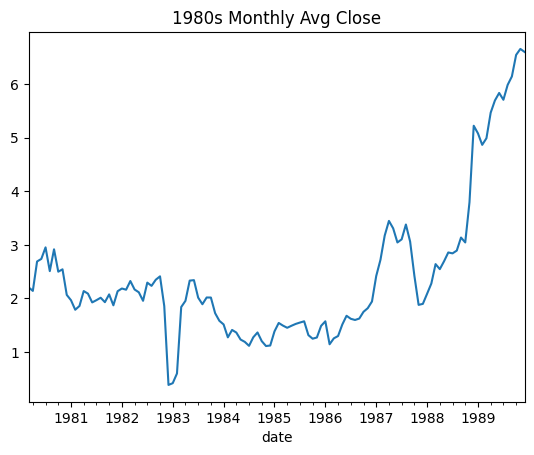

/tmp/ipykernel_1310/79599554.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = df['close'].resample('M').mean()


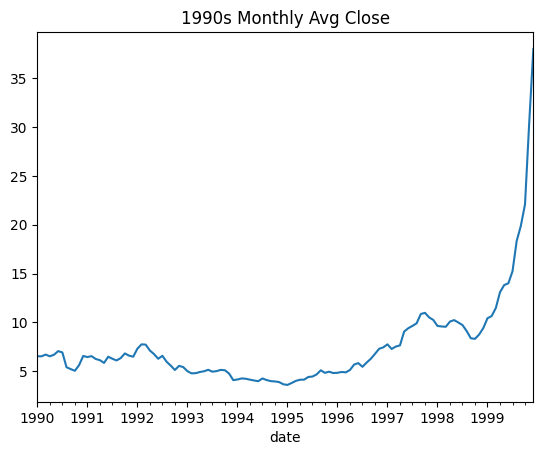

/tmp/ipykernel_1310/79599554.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = df['close'].resample('M').mean()


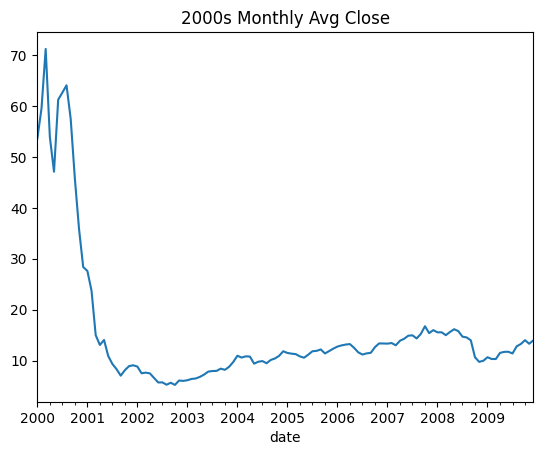

/tmp/ipykernel_1310/79599554.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = df['close'].resample('M').mean()


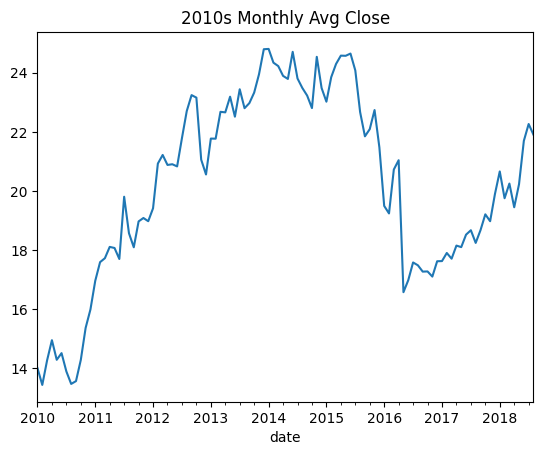

In [ ]:
#Monthly Average Close (Time Series)

for decade, df in decades.items():
    monthly = df['close'].resample('M').mean()
    monthly.plot(title=f"{decade}s Monthly Avg Close")
    plt.show()


##Analyze the visualizations to identify patterns or anomalies that are consistent or have changed across decades.
##Across the plot, average close show a clear upward trajectory over time, with distinct decade level patterns that highlight how fast the market evolved. In the 1970s, the average close hovered near 20, reflecting a relatively modest pricing environment. By the 1980s, average closes approached 45 before the decade ended, marking a noticeable acceleration. The 1990s continued this momentum, with average closes rising to around 140 shortly after the midpoint of the decade. The early 2000s saw an even sharper increase, with average closets reaching nearly 400 at the beginning of the decade, illustrating the impact of technological growth and expanding global markets. In the 2010s, average closes returned closer to 140, showing corrections but still maintaining a much higher baseline than earlier decades. Overall, the progression demonstrates a long term rise in stock prices and a fast moving market shaped by structural, technological, and economic changes across time.

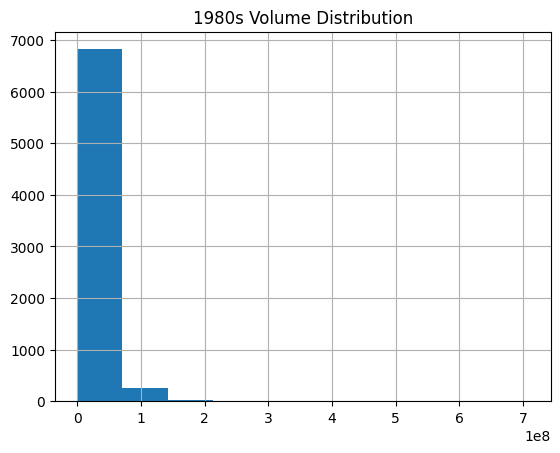

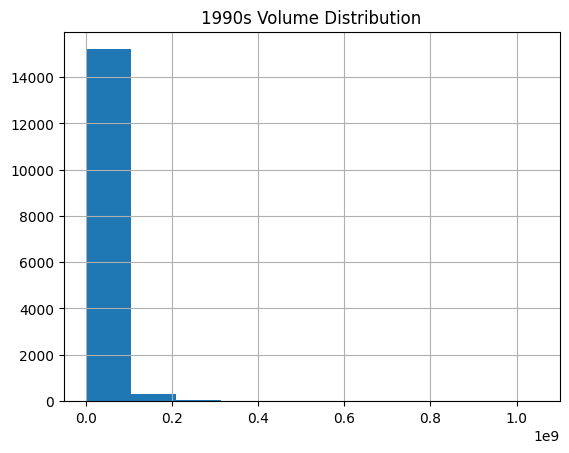

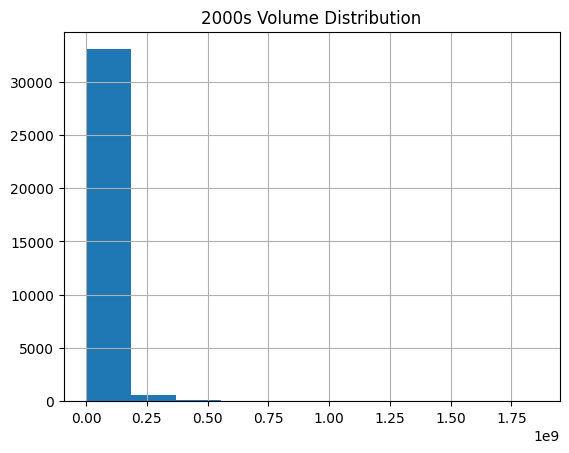

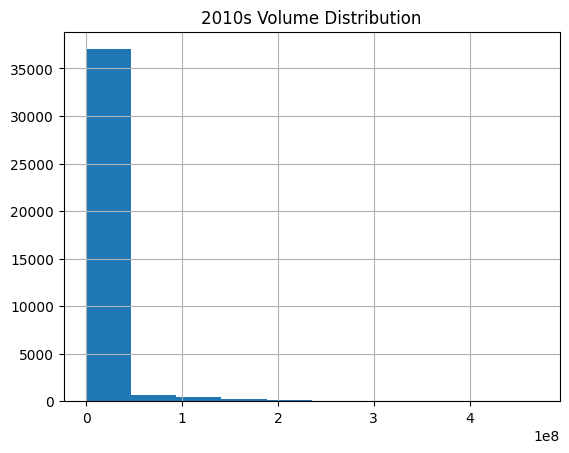

In [ ]:
#Volume Distribution (Histogram)
for decade, df in decades.items():
    df['volume'].hist(bins=10)
    plt.title(f"{decade}s Volume Distribution")
    plt.show()


##When I look at this histogram for the 1970s, I can see that trading volume is heavily concentrated at very low values. Most of the bars pile up near the left side of the plot, which tells that small volume trades were extremely common during this decade. As volume increases, the frequency drops sharply, meaning high volume trading was rare. Overall, the distribution is strongly skewed, showing that the 1970s market operated with consistently low trading activity.

##When I look at the histograms for the 1980s, 1990s, 2000s, and 2010s, I can see that the trading volume is extremely concentrated near zero, with one very tall bar dominating the plot. This tells that most trading activity in these decades happened at very low volume levels, and higher volume trades were extremely rare. The distribution stays almost identical across all four decades, showing a consistent pattern of low volume trading throughout these periods


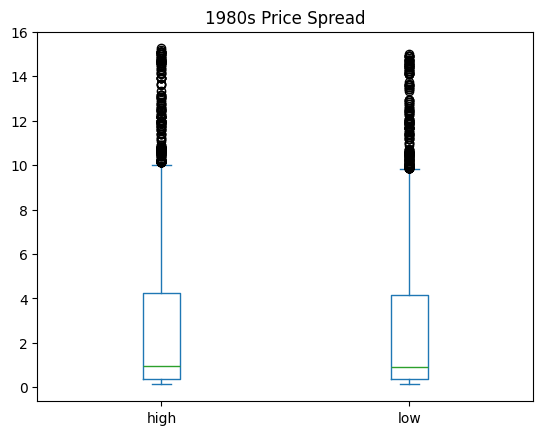

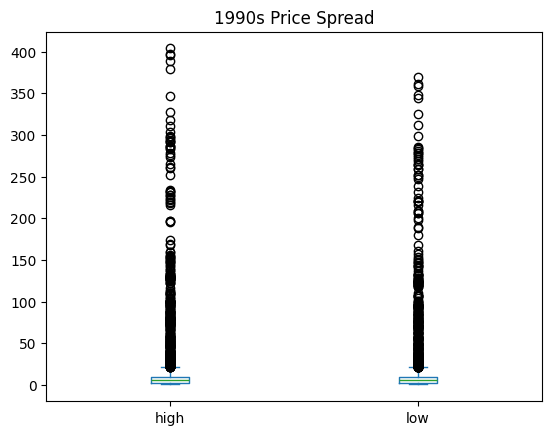

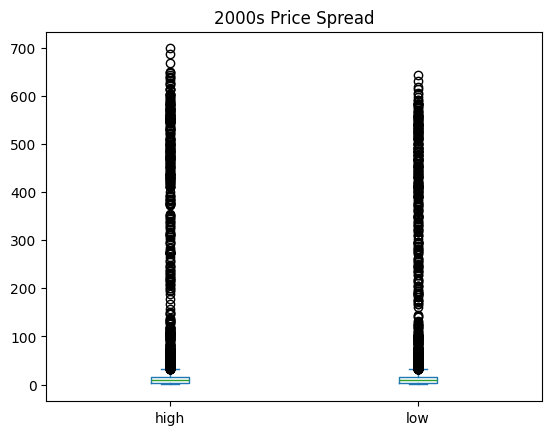

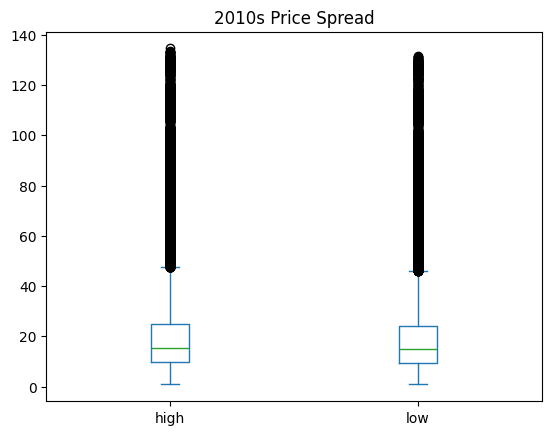

In [ ]:
import matplotlib.pyplot as plt
#Price Spread (Box Plot)
for decade, df in decades.items():
    df[['high','low']].plot(kind='box')
    plt.title(f"{decade}s Price Spread")
    plt.show()

##When I look at the 1970s price spread box plot, I can see that both the high and low prices have a wide range, with several outliers appearing above the whiskers. This tells that price movements during this decade were more volatile, with occasionally extreme values pushing beyond the typical range. The medians for high and low prices are well separated, showing a consistent gap between the two, but the presence of multiple outliers highlights that the 1970s had more irregular price spikes compared to later decades.

##When I look at the 1980s price spread box plot, I can see that both the high and low prices have a much wider spread compared to the 1970s. The boxes and whiskers extend over a large range, and there are many outliers above the whiskers, which tells me that the decade experienced strong volatility and frequent extreme price movements. Even though the medians for high and low prices remain clearly separated, the large number of outliers shows that the 1980s had more irregular spikes and fluctuations than the previous decade.

##When I look at the 1990s price spread box plot, I can see that both the high and low prices have a very large spread, with most values clustered near the bottom and several extreme outliers stretching far upward. This tells that the decade had significant volatility, with occasional price spikes that sit far outside the typical range. Even though the central part of the distribution is tight, the presence of these very high outliers shows that the 1990s experienced some unusually large price movements.

##When I look at the 2000s price spread box plot, I can see that both the high and low prices have an extremely wide range, with many outliers stretching far above the main distribution. This tells me that the decade experienced strong volatility and frequent extreme price movements. Even though the central boxes stay relatively compact, the large number of very high outliers shows that the 2000s had some of the most dramatic price spikes compared to earlier decades.

##When I look at the 2010s price spread box plot, I can see that both the high and low prices stay tightly clustered near the bottom of the range, with only a handful of outliers stretching upward. Compared to earlier decades, this distribution shows much fewer extreme values, meaning the 2010s had the least volatility and the smallest number of unusual price spikes.

In [ ]:
df_cleaned = df.to_csv('df_cleaned.csv', index=False)
print("DataFrame 'df' saved to df_cleaned.csv")

DataFrame 'df' saved to df_cleaned.csv


In [ ]:
from google.colab import files
files.download('df_cleaned.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

#Save in google drive
df.to_csv('/content/drive/MyDrive/df_cleaned.csv', index=False)
print("DataFrame 'df' saved to df_cleaned.csv")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
DataFrame 'df' saved to df_cleaned.csv


##Colab link https://colab.research.google.com/drive/1GqurVe7xx10P8lWQKdKNlV-BzR-TJizL?usp=sharing


## https://github.com/christinengalle19-collab/Christine-Tsafong-BIA-PROJECTS.git